## Regression Task: Fuel Efficiency Prediction

In [1]:
# Regression Task: Fuel Efficiency Prediction
# Load the Auto MPG dataset directly from UCI

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Define column names (the dataset has no header row)
column_names = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

# URL of the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Read the data, split by whitespace, treat "?" as missing values
df = pd.read_csv(
    url,
    names=column_names,
    na_values="?",
    sep=r"\s+"
)

# 'car_name' is a textual feature and is not useful for regression, so it is excluded from prediction.
df = df.drop(columns=["car_name"])

# Display first rows to verify loading
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


**2.1 Exploratory Data Analysis**


In [2]:
# Checking for Missing Values

df.isnull().sum()

# 'horsepower' has 6 missing values that must be handled (models cannot use NaN).

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


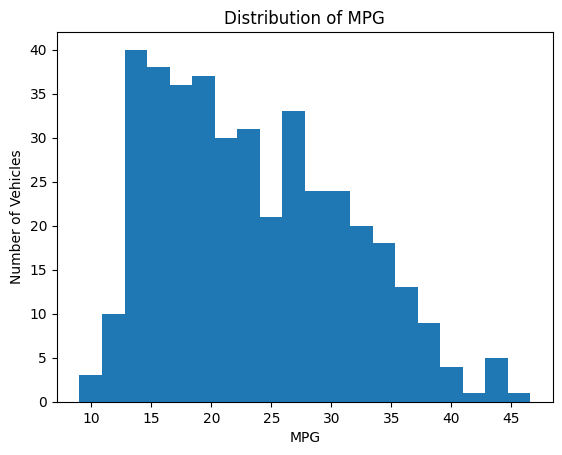

In [3]:
# Target distribution (mpg)
plt.figure()
plt.hist(df["mpg"], bins=20)
plt.xlabel("MPG")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of MPG")
plt.show()

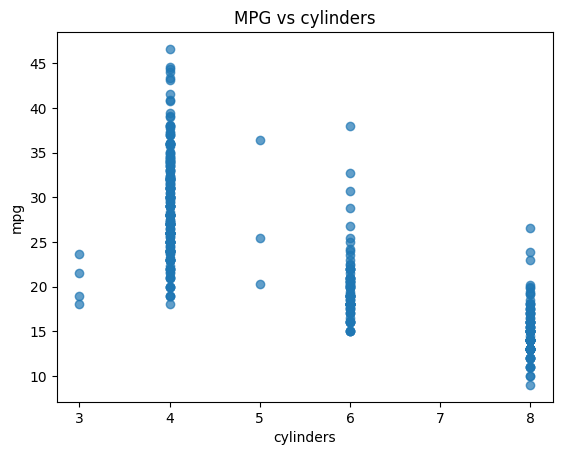

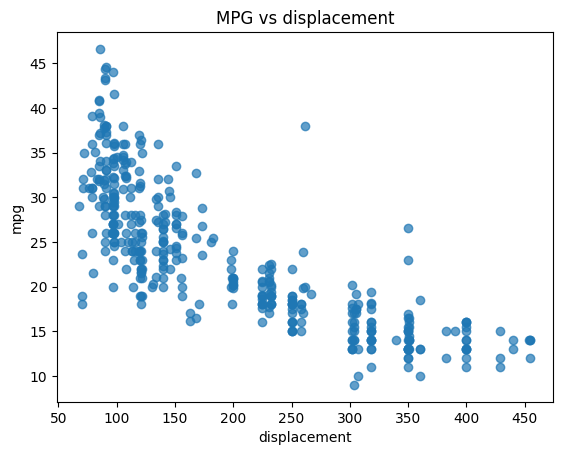

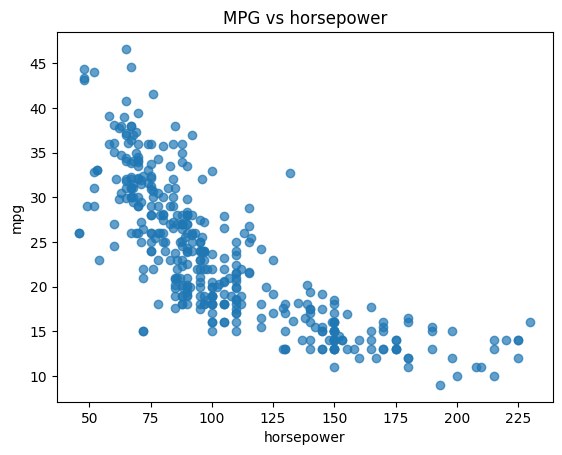

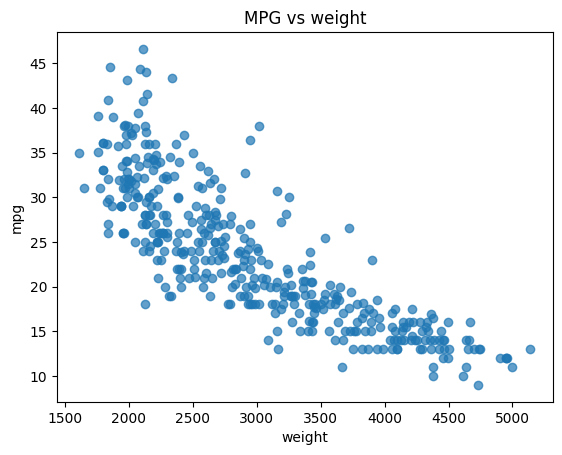

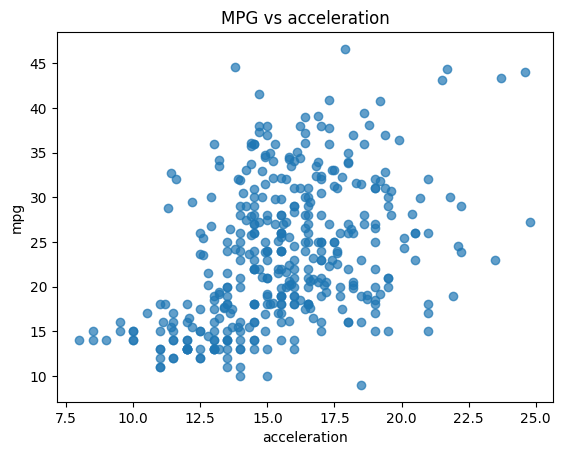

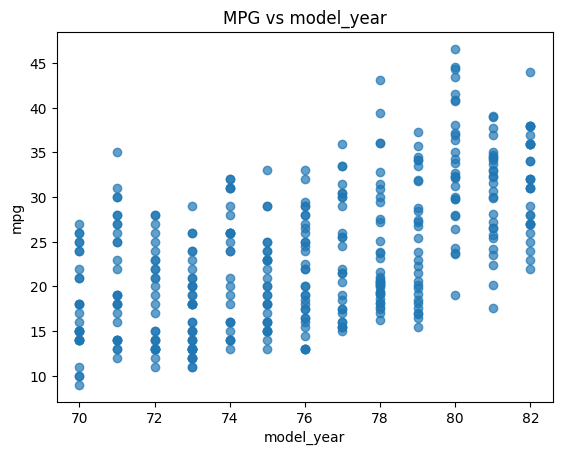

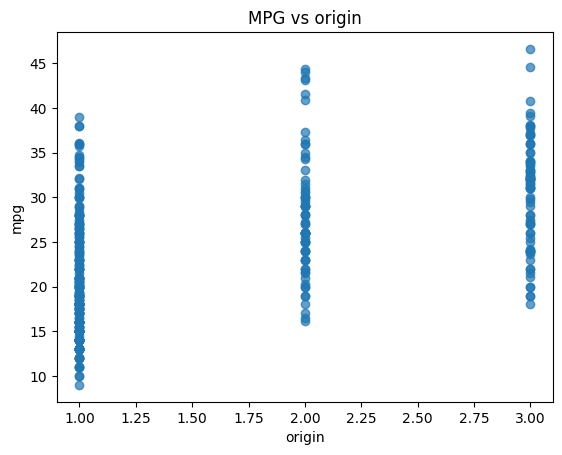

In [4]:
# Feature-target relationships (each feature vs. mpg)
# We visualize the relationship between every feature and the target as required.

features_to_plot = ["cylinders", "displacement", "horsepower", "weight",
                    "acceleration", "model_year", "origin"]

for feat in features_to_plot:
    plt.figure()
    plt.scatter(df[feat], df["mpg"], alpha=0.7)
    plt.xlabel(feat)
    plt.ylabel("mpg")
    plt.title(f"MPG vs {feat}")
    plt.show()

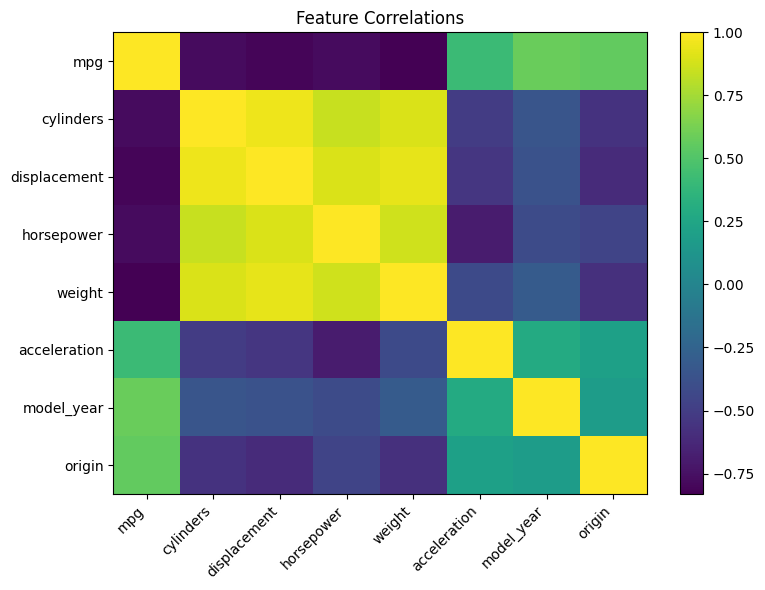

In [5]:
# Correlation among numeric features
# (car_name is text, so exclude it here)

numeric_cols = ["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

**2.2 Dataset and Preprocessing**

In [6]:
from sklearn.model_selection import train_test_split

# car_name is a textual feature and was removed earlier, so it is excluded from prediction.
df_model = df.drop(columns=["car_name"], errors="ignore")

# Define target and features (as required)
y = df_model["mpg"].values
X = df_model.drop(columns=["mpg"])

# Train/Val/Test split
# 1) Hold out test set first (never touched during model selection)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# 2) Split remaining into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=SEED
)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 254
Val size: 64
Test size: 80


In [7]:
# Preprocessing using a Pipeline:
# Handle missing values in horsepower using mean imputation
#Standardize features (helps KNN + polynomial stability + SGD training)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define which features are numerical and which are categorical
numeric_features = ["cylinders","displacement","horsepower","weight","acceleration","model_year"]
categorical_features = ["origin"]

# Preprocessing for numerical features:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical feature (origin)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine the transformations for numeric and categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Quick check that preprocessing works
_ = preprocess.fit_transform(X_train)
print("Preprocessing OK. Transformed train shape:", _.shape)

Preprocessing OK. Transformed train shape: (254, 9)


**2.3 Linear Regression Baseline**

In [8]:
# Helper evaluation function (MSE/RMSE/MAE/R^2)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

Linear Regression (Validation):
MSE: 12.89804482678648
RMSE: 3.5913848062810647
MAE: 2.7963707131248263
R^2: 0.8145099292084221


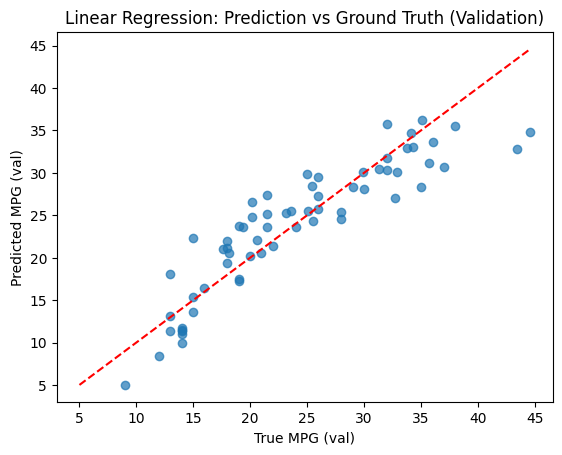

In [9]:
from sklearn.linear_model import LinearRegression

lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# Train on train set
lin_model.fit(X_train, y_train)

# Evaluate on validation (used for model comparison / discussion)
y_val_pred = lin_model.predict(X_val)
mse, rmse, mae, r2 = regression_metrics(y_val, y_val_pred)

print("Linear Regression (Validation):")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)

# Prediction vs Ground Truth (VAL)
plt.figure()
plt.scatter(y_val, y_val_pred, alpha=0.7)
plt.xlabel("True MPG (val)")
plt.ylabel("Predicted MPG (val)")
plt.title("Linear Regression: Prediction vs Ground Truth (Validation)")

# Ideal line y=x
mn = min(y_val.min(), y_val_pred.min())
mx = max(y_val.max(), y_val_pred.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.show()

**2.4 Polynomial Regression and Model Complexity**


Best polynomial degree (by VAL MSE): 2


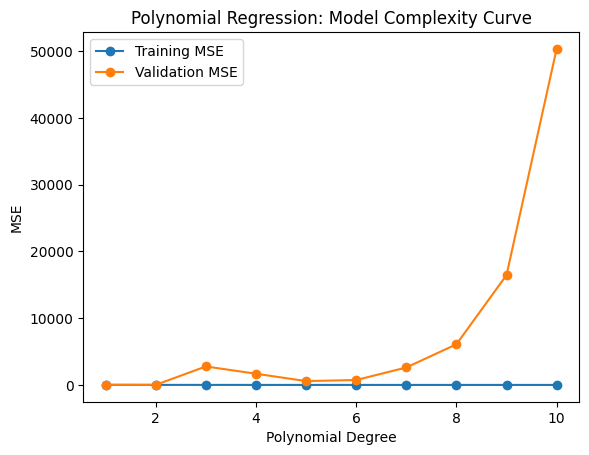

In [10]:
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1, 11)
train_mse_list = []
val_mse_list = []

for d in degrees:
    poly_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])

    poly_model.fit(X_train, y_train)

    # Train error
    y_train_pred = poly_model.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)

    # Val error
    y_val_pred = poly_model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)

best_degree = degrees[int(np.argmin(val_mse_list))]
print("Best polynomial degree (by VAL MSE):", best_degree)

# Plot complexity curve
plt.figure()
plt.plot(list(degrees), train_mse_list, marker="o", label="Training MSE")
plt.plot(list(degrees), val_mse_list, marker="o", label="Validation MSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Polynomial Regression: Model Complexity Curve")
plt.legend()
plt.show()

**2.5 K-Nearest Neighbors (KNN) Regression**


Best k (by VAL MSE): 4


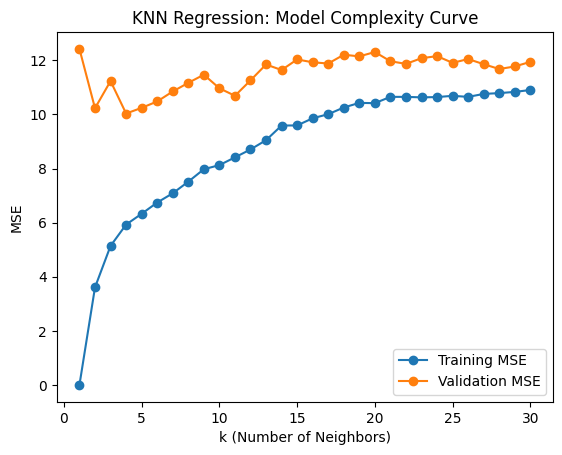

In [11]:
# KNN Regression - Train and validation error as a function of k

from sklearn.neighbors import KNeighborsRegressor

# Try different k values to study model complexity
k_values = range(1, 31)
knn_train_mse = []
knn_val_mse = []

for k in k_values:
    knn_model = Pipeline(steps=[
        ("preprocess", preprocess),  # scaling is important for distance-based models
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])

    # Fit model on training set
    knn_model.fit(X_train, y_train)

    # Predict on train and validation sets
    y_train_pred = knn_model.predict(X_train)
    y_val_pred = knn_model.predict(X_val)

    # Store MSE values for comparison
    knn_train_mse.append(mean_squared_error(y_train, y_train_pred))
    knn_val_mse.append(mean_squared_error(y_val, y_val_pred))

# Select best k based on validation MSE
best_k = k_values[int(np.argmin(knn_val_mse))]
print("Best k (by VAL MSE):", best_k)

# Plot training and validation error vs k
plt.figure()
plt.plot(list(k_values), knn_train_mse, marker="o", label="Training MSE")
plt.plot(list(k_values), knn_val_mse, marker="o", label="Validation MSE")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("MSE")
plt.title("KNN Regression: Model Complexity Curve")
plt.legend()
plt.show()

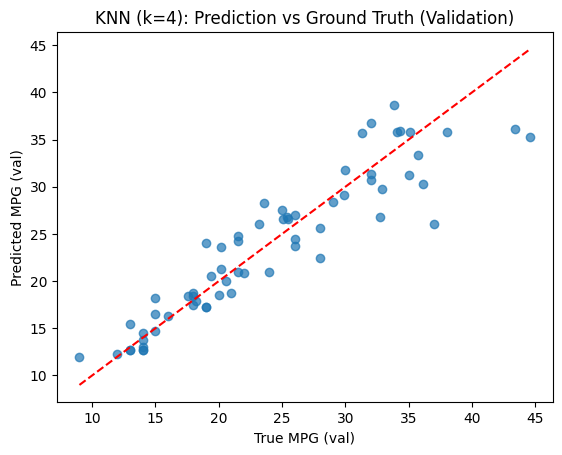

In [12]:
# KNN Regression - Prediction vs Ground Truth (VAL)

# Build final KNN model with selected k
best_knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])

# Train on training set
best_knn_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = best_knn_model.predict(X_val)

# Plot prediction vs ground truth
plt.figure()
plt.scatter(y_val, y_val_pred, alpha=0.7)
plt.xlabel("True MPG (val)")
plt.ylabel("Predicted MPG (val)")
plt.title(f"KNN (k={best_k}): Prediction vs Ground Truth (Validation)")

# Ideal y=x reference line
mn = min(y_val.min(), y_val_pred.min())
mx = max(y_val.max(), y_val_pred.max())
plt.plot([mn, mx], [mn, mx], "r--")

plt.show()

**2.6 Optimization Behavior**



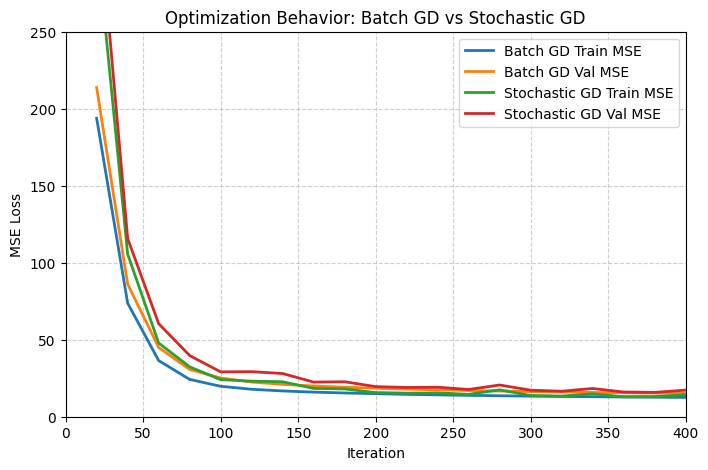

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# preprocess train and val
X_train_proc = preprocess.fit_transform(X_train)
X_val_proc = preprocess.transform(X_val)

# add bias column
X_train_gd = np.c_[np.ones(X_train_proc.shape[0]), X_train_proc]
X_val_gd = np.c_[np.ones(X_val_proc.shape[0]), X_val_proc]

# convert y to numpy arrays
y_train_arr = np.array(y_train)
y_val_arr = np.array(y_val)

# parameters
eta = 0.01
max_updates = 3000
record_every = 20

n_samples, n_features = X_train_gd.shape

# initialize weights with same starting point
np.random.seed(SEED)
w_batch = np.random.randn(n_features) * 0.01
w_stoch = w_batch.copy()

# store losses
batch_train_loss, batch_val_loss = [], []
stoch_train_loss, stoch_val_loss = [], []
batch_x, stoch_x = [], []

#  Batch Gradient Descent
for t in range(1, max_updates + 1):
    y_pred_train = X_train_gd @ w_batch
    grad = (2 / n_samples) * X_train_gd.T @ (y_pred_train - y_train_arr)
    w_batch -= eta * grad

    if t % record_every == 0:
        y_tr_pred = X_train_gd @ w_batch
        y_v_pred = X_val_gd @ w_batch
        batch_train_loss.append(mean_squared_error(y_train_arr, y_tr_pred))
        batch_val_loss.append(mean_squared_error(y_val_arr, y_v_pred))
        batch_x.append(t)

#  Stochastic Gradient Descent
idx = np.random.permutation(n_samples)
ptr = 0

for t in range(1, max_updates + 1):
    if ptr == n_samples:
        idx = np.random.permutation(n_samples)
        ptr = 0

    i = idx[ptr]
    ptr += 1

    xi = X_train_gd[i:i+1]
    yi = y_train_arr[i:i+1]

    y_pred_i = xi @ w_stoch
    grad_i = 2 * xi.T @ (y_pred_i - yi)
    w_stoch -= eta * grad_i.ravel()

    if t % record_every == 0:
        y_tr_pred = X_train_gd @ w_stoch
        y_v_pred = X_val_gd @ w_stoch
        stoch_train_loss.append(mean_squared_error(y_train_arr, y_tr_pred))
        stoch_val_loss.append(mean_squared_error(y_val_arr, y_v_pred))
        stoch_x.append(t)

plt.figure(figsize=(8,5))

plt.plot(batch_x, batch_train_loss, label="Batch GD Train MSE", linewidth=2)
plt.plot(batch_x, batch_val_loss, label="Batch GD Val MSE", linewidth=2)
plt.plot(stoch_x, stoch_train_loss, label="Stochastic GD Train MSE", linewidth=2)
plt.plot(stoch_x, stoch_val_loss, label="Stochastic GD Val MSE", linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Optimization Behavior: Batch GD vs Stochastic GD")
plt.xlim(0, 400)
plt.ylim(0, 250)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


**2.7 Model Comparison and Final Model Selection**


In [14]:
# Predictive performance comparison for the final regression models
# In this block we compute the main validation metrics for the models
# so we can summarize and compare them later in Section 2.7.

import numpy as np

# -----------------------------
# Linear Regression baseline
# -----------------------------
linear_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_val_pred_linear = linear_model.predict(X_val)

linear_val_mse, linear_val_rmse, linear_val_mae, linear_val_r2 = regression_metrics(y_val, y_val_pred_linear)

print("Linear Regression")
print(f"Validation MSE:  {linear_val_mse:.4f}")
print(f"Validation RMSE: {linear_val_rmse:.4f}")
print(f"Validation MAE:  {linear_val_mae:.4f}")
print(f"Validation R^2:  {linear_val_r2:.4f}")

print("-" * 40)

# -----------------------------
# Polynomial Regression
# -----------------------------
final_poly_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("model", LinearRegression())
])

final_poly_model.fit(X_train, y_train)
y_val_pred_poly = final_poly_model.predict(X_val)

poly_val_mse, poly_val_rmse, poly_val_mae, poly_val_r2 = regression_metrics(y_val, y_val_pred_poly)

print("Polynomial Regression")
print(f"Best degree: {best_degree}")
print(f"Validation MSE:  {poly_val_mse:.4f}")
print(f"Validation RMSE: {poly_val_rmse:.4f}")
print(f"Validation MAE:  {poly_val_mae:.4f}")
print(f"Validation R^2:  {poly_val_r2:.4f}")

print("-" * 40)

# -----------------------------
# KNN Regression
# -----------------------------
final_knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])

final_knn_model.fit(X_train, y_train)
y_val_pred_knn = final_knn_model.predict(X_val)

knn_val_mse, knn_val_rmse, knn_val_mae, knn_val_r2 = regression_metrics(y_val, y_val_pred_knn)

print("KNN Regression")
print(f"Best k: {best_k}")
print(f"Validation MSE:  {knn_val_mse:.4f}")
print(f"Validation RMSE: {knn_val_rmse:.4f}")
print(f"Validation MAE:  {knn_val_mae:.4f}")
print(f"Validation R^2:  {knn_val_r2:.4f}")


# Put all final validation results into one summary table
summary_df = pd.DataFrame({
    "Model": ["Linear Regression", f"Polynomial Regression (deg={best_degree})", f"KNN Regression (k={best_k})"],
    "MSE": [linear_val_mse, poly_val_mse, knn_val_mse],
    "RMSE": [linear_val_rmse, poly_val_rmse, knn_val_rmse],
    "MAE": [linear_val_mae, poly_val_mae, knn_val_mae],
    "R^2": [linear_val_r2, poly_val_r2, knn_val_r2]
})

summary_df

Linear Regression
Validation MSE:  12.8980
Validation RMSE: 3.5914
Validation MAE:  2.7964
Validation R^2:  0.8145
----------------------------------------
Polynomial Regression
Best degree: 2
Validation MSE:  11.7910
Validation RMSE: 3.4338
Validation MAE:  2.3339
Validation R^2:  0.8304
----------------------------------------
KNN Regression
Best k: 4
Validation MSE:  10.0326
Validation RMSE: 3.1674
Validation MAE:  2.3109
Validation R^2:  0.8557


,Model,MSE,RMSE,MAE,R^2
0,Linear Regression,12.898045,3.591385,2.796371,0.814510
1,Polynomial Regression (deg=2),11.791016,3.433805,2.333870,0.830430
2,KNN Regression (k=4),10.032578,3.167425,2.310938,0.855719


In [15]:

# Select final model based on the lowest validation MSE
candidates = {
    "Linear Regression": (linear_val_mse, "linear"),
    f"Polynomial Regression (deg={best_degree})": (poly_val_mse, "poly"),
    f"KNN Regression (k={best_k})": (knn_val_mse, "knn")
}

final_choice = min(candidates, key=lambda k: candidates[k][0])
final_model_type = candidates[final_choice][1]

print("\nSelected final model based on the lowest validation MSE:", final_choice)


Selected final model based on the lowest validation MSE: KNN Regression (k=4)


In [16]:
# retrain the selected model on train+val, then evaluate once on the test set

# merge train and validation sets for final training
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = np.concatenate([y_train, y_val])

# get the model type chosen from the validation comparison
choice_type = candidates[final_choice][1]

# build the final model based on the selected type
if choice_type == "linear":
    final_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ])
elif choice_type == "poly":
    final_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("model", LinearRegression())
    ])
else:  # knn
    final_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsRegressor(n_neighbors=best_k))
    ])

# fit on the full training data (train + val)
final_model.fit(X_final_train, y_final_train)

# final evaluation on test (only done once, after model selection)
y_test_pred = final_model.predict(X_test)
mse, rmse, mae, r2 = regression_metrics(y_test, y_test_pred)

print("\nFinal Model Performance on TEST:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)


Final Model Performance on TEST:
MSE: 5.345578125
RMSE: 2.312050632014792
MAE: 1.9125
R^2: 0.9005777999777045
